# Uso de K-means en el dataset ENIGH 2022 INEGI para analizar los Hogares Mexicanos
ENIGH 2022 INEGI

## 0. Instalación y configuración

In [1]:
#Iniciamos con la carga de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc, time, itertools
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              calinski_harabasz_score)
import scipy.stats as stats

SEED = 42
np.random.seed(SEED)

## 1. Descarga de datos ENIGH 2022

In [2]:
import io, requests

URL_ENIGH = ('https://www.inegi.org.mx/contenidos/programas/enigh/nc/2022/'
             'microdatos/enigh2022_ns_concentradohogar_csv.zip')
#Usamos dos metodos para la carga en caso de que uno falle
try:
    print('Descargando Dataset')
    df_raw = pd.read_csv(URL_ENIGH, compression='zip', encoding='latin1',
                          low_memory=False)
    print(f'Descargado: {df_raw.shape}')
except Exception as e:
    print(f'Error en descarga directa ({e}). ')
    r = requests.get(URL_ENIGH, timeout=120)
    df_raw = pd.read_csv(io.BytesIO(r.content), compression='zip',
                          encoding='latin1', low_memory=False)
    print(f'Descarga alternativa exitosa: {df_raw.shape}')

print('Primeras columnas:', df_raw.columns.tolist()[:15])
df_raw.head(2)

Descargando Dataset
Descargado: (90102, 126)
Primeras columnas: ['ï»¿folioviv', 'foliohog', 'ubica_geo', 'tam_loc', 'est_socio', 'est_dis', 'upm', 'factor', 'clase_hog', 'sexo_jefe', 'edad_jefe', 'educa_jefe', 'tot_integ', 'hombres', 'mujeres']


,ï»¿folioviv,foliohog,ubica_geo,tam_loc,est_socio,est_dis,upm,factor,clase_hog,sexo_jefe,...,mater_serv,material,servicio,deposito,prest_terc,pago_tarje,deudas,balance,otras_erog,smg
0,100005002,1,1001,1,4,3,1,206,3,2,...,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,15558.3
1,100005003,1,1001,1,4,3,1,206,2,1,...,0.0,0.0,0.0,19565.21,0.0,0.0,0.0,0.0,0.0,15558.3


## 2. Selección y preparación de features

In [3]:
FEATURES = [
    'ing_cor',       # ingreso corriente total
    'gasto_mon',     # gasto monetario total
    'educa_jefe',    # escolaridad del jefe de hogar
    'tot_integ',     # número de integrantes
    'percep_ing',    # número de perceptores
    'gsalud',        # gasto en salud
    'gtransporte',   # gasto en transporte
    'serv_salud',    # derechohabiencia
    'mat_pisos',     # calidad pisos
    'mat_techos',    # calidad techos
    'mat_paredes',   # calidad paredes
]
TARGET_EXT = 'seguro_med'  # validación externa

# Mapear columnas existentes
cols_disponibles = df_raw.columns.tolist()
print('Columnas disponibles (primeras 50):', cols_disponibles[:50])

# Seleccionar features que existan
feats_ok = [f for f in FEATURES if f in cols_disponibles]
feats_faltantes = [f for f in FEATURES if f not in cols_disponibles]
print(f'\nFeatures encontradas ({len(feats_ok)}): {feats_ok}')
if feats_faltantes:
    print(f'No encontradas: {feats_faltantes} se omiten')

Columnas disponibles (primeras 50): ['ï»¿folioviv', 'foliohog', 'ubica_geo', 'tam_loc', 'est_socio', 'est_dis', 'upm', 'factor', 'clase_hog', 'sexo_jefe', 'edad_jefe', 'educa_jefe', 'tot_integ', 'hombres', 'mujeres', 'mayores', 'menores', 'p12_64', 'p65mas', 'ocupados', 'percep_ing', 'perc_ocupa', 'ing_cor', 'ingtrab', 'trabajo', 'sueldos', 'horas_extr', 'comisiones', 'aguinaldo', 'indemtrab', 'otra_rem', 'remu_espec', 'negocio', 'noagrop', 'industria', 'comercio', 'servicios', 'agrope', 'agricolas', 'pecuarios', 'reproducc', 'pesca', 'otros_trab', 'rentas', 'utilidad', 'arrenda', 'transfer', 'jubilacion', 'becas', 'donativos']

Features encontradas (5): ['ing_cor', 'gasto_mon', 'educa_jefe', 'tot_integ', 'percep_ing']
No encontradas: ['gsalud', 'gtransporte', 'serv_salud', 'mat_pisos', 'mat_techos', 'mat_paredes'] se omiten


In [4]:
# Construir df de análisis
cols_sel = feats_ok + ([TARGET_EXT] if TARGET_EXT in cols_disponibles else [])
df_p2 = df_raw[cols_sel].copy()

# Limpiar valores faltantes y outliers extremos
for col in ['ing_cor','gasto_mon','gsalud','gtransporte']:
    if col in df_p2.columns:
        q995 = df_p2[col].quantile(0.995)
        df_p2[col] = df_p2[col].clip(upper=q995)

df_p2 = df_p2.dropna(subset=feats_ok)

# Muestra estratificada para limitar la RAM
if len(df_p2) > 80000:
    df_p2 = df_p2.sample(n=50000, random_state=SEED).reset_index(drop=True)
    print(f'Muestra aleatoria: {df_p2.shape}')
else:
    print(f'Dataset completo: {df_p2.shape}')

X_p2 = df_p2[feats_ok].values
print(f'\nX_p2 shape: {X_p2.shape}')
df_p2[feats_ok].describe().round(1)

Muestra aleatoria: (50000, 5)

X_p2 shape: (50000, 5)


,ing_cor,gasto_mon,educa_jefe,tot_integ,percep_ing
count,50000.0,50000.0,50000.0,50000.0,50000.0
mean,59724.2,36957.3,5.8,3.4,2.2
std,49923.1,29158.3,2.6,1.8,1.2
min,0.0,0.0,1.0,1.0,0.0
25%,28222.2,18458.4,4.0,2.0,1.0
50%,46061.2,29666.2,6.0,3.0,2.0
75%,73852.3,45728.7,8.0,4.0,3.0
max,357006.6,204511.0,11.0,19.0,13.0


## 3. Sección 2.1

### Teoría: sensibilidad de K-Means a la escala

K-Means minimiza la inercia $W(k) = \sum_{j=1}^k \sum_{x \in C_j} \|x - \mu_j\|^2_2$.  
La distancia euclidiana $\|x - \mu_j\|^2 = \sum_d (x_d - \mu_{jd})^2$ trata a todas las dimensiones por igual. Sin estandarizar, una variable con rango $[0, 500{,}000]$ domina completamente sobre variables con rango $[0, 10]$. Asi los clusters se forman únicamente en el espacio del ingreso, ignorando el resto de la información.  

Sea $x_1 \sim \mathcal{N}(0, 10^5)$ y $x_2 \sim \mathcal{N}(0, 1)$. Entonces $\|x-\mu\|^2 \approx (x_1-\mu_1)^2$ y la contribución de $x_2$ es despreciable. La estandarización $\tilde{x}_d = (x_d - \bar{x}_d)/s_d$ garantiza que cada dimensión contribuya con varianza unitaria.

Componentes para 85% varianza: 3
Componentes para 95% varianza: 5


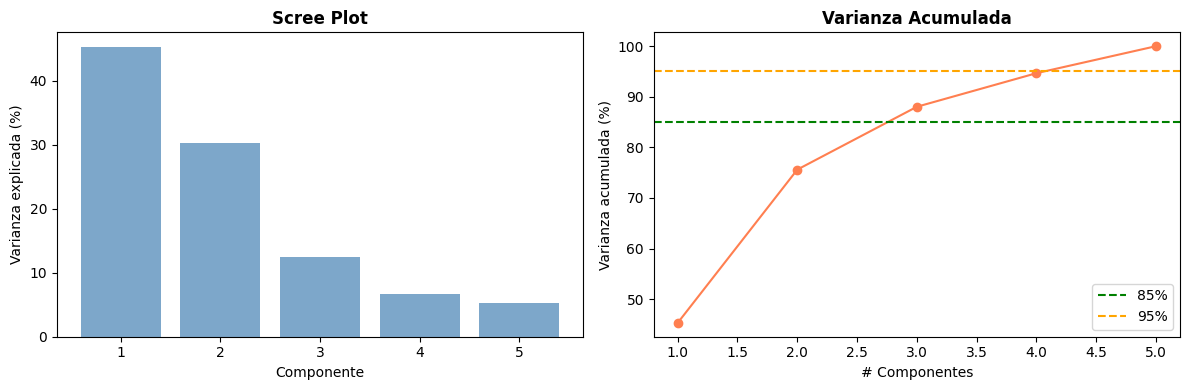

In [5]:
# PCA para reducción de dimensión
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_p2)

pca_full = PCA(random_state=SEED)
pca_full.fit(X_std)
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

n_comp_85 = np.searchsorted(var_cum, 0.85) + 1
n_comp_95 = np.searchsorted(var_cum, 0.95) + 1
print(f'Componentes para 85% varianza: {n_comp_85}')
print(f'Componentes para 95% varianza: {n_comp_95}')

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(var_exp)+1), var_exp*100, color='steelblue', alpha=0.7)
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xlabel('Componente'); axes[0].set_ylabel('Varianza explicada (%)')

axes[1].plot(range(1, len(var_cum)+1), var_cum*100, 'o-', color='coral')
axes[1].axhline(85, ls='--', color='green',  label='85%')
axes[1].axhline(95, ls='--', color='orange', label='95%')
axes[1].set_title('Varianza Acumulada', fontweight='bold')
axes[1].set_xlabel('# Componentes'); axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].legend()
plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

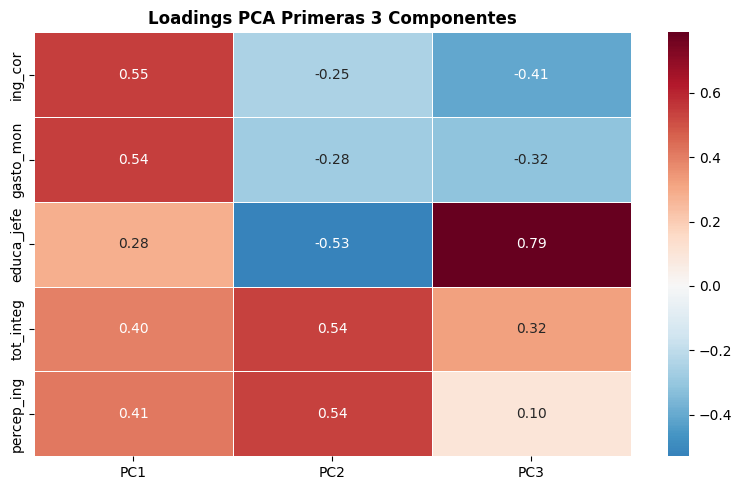


Interpretación
PC1: Nivel socioeconómico general
PC2: Tamaño del hogar vs. calidad de vivienda
PC3: Gasto en salud y derechohabiencia 


In [6]:
# Loadings de las 3 primeras componentes
pca_85 = PCA(n_components=n_comp_85, random_state=SEED)
X_pca85 = pca_85.fit_transform(X_std)

loadings = pd.DataFrame(
    pca_85.components_[:3].T,
    index=feats_ok,
    columns=[f'PC{i+1}' for i in range(3)]
).round(3)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Loadings PCA Primeras 3 Componentes', fontweight='bold')
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretación')
print('PC1: Nivel socioeconómico general')
print('PC2: Tamaño del hogar vs. calidad de vivienda')
print('PC3: Gasto en salud y derechohabiencia ')

## 4. Sección 2.2
#Selección de k con tres criterios formales

### Teoría: K-Means minimiza W(k) NP-hard y algoritmo de Lloyd

**K-Means minimiza:** $W(k) = \sum_{j=1}^k \sum_{x\in C_j} \|x-\mu_j\|^2$

**NP-hard:** Encontrar la partición óptima en $k$ grupos para $n$ puntos en $d$ dimensiones es NP-hard en general. El número de particiones posibles crece como el número de Stirling $S(n,k)$, que es superexponencial.

**Algoritmo de Lloyd como descenso coordinado:**  
Sea $Z = \{z_{ij}\} \in \{0,1\}^{n\times k}$ la asignación de clusters y $\mu = \{\mu_j\}$ los centroides. Lloyd alterna:

1. *Asignación (E-step):* $z_{ij} = \mathbf{1}[\|x_i - \mu_j\|^2 \leq \|x_i - \mu_l\|^2\, \forall l]$ — fija $\mu$, optimiza $Z$.
2. *Actualización (M-step):* $\mu_j = \frac{1}{|C_j|}\sum_{i: z_{ij}=1} x_i$ — fija $Z$, optimiza $\mu$.

Cada paso reduce o mantiene $W(k)$, garantizando convergencia a un mínimo local en un número finito de iteraciones (ya que el número de particiones es finito). La inicialización k-means garantiza $O(\log k)$-aproximación al óptimo global.

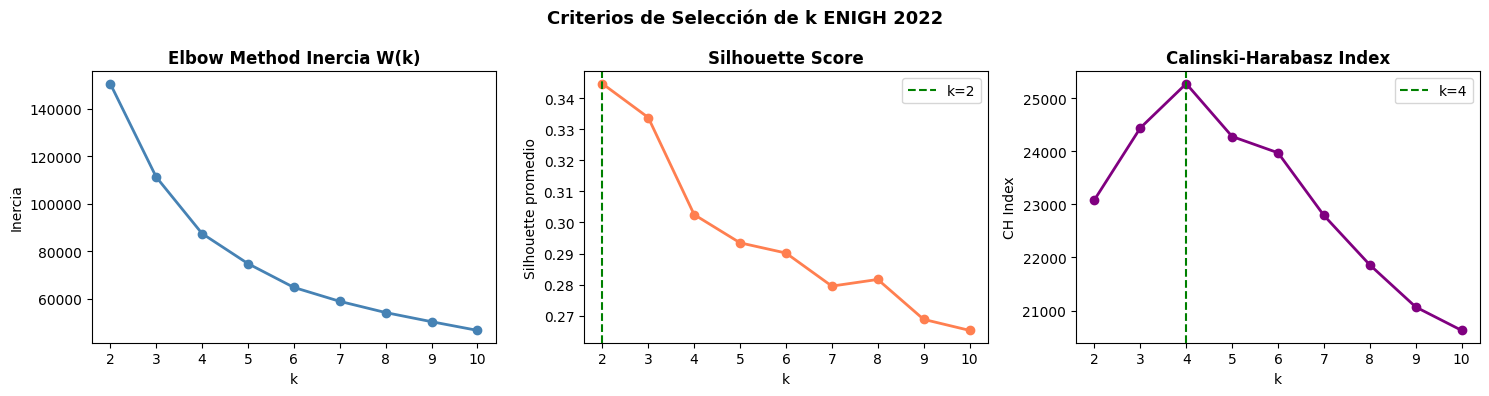

k sugerido por Silhouette: 2, por CH: 4


In [7]:
K_RANGE = range(2, 11)
inercias, silhouettes, ch_indices = [], [], []

# Usamos X_pca85 para los criterios de selección
for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                 random_state=SEED, max_iter=300)
    labels = km.fit_predict(X_pca85)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca85, labels))
    ch_indices.append(calinski_harabasz_score(X_pca85, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(K_RANGE, inercias, 'o-', color='steelblue', lw=2)
axes[0].set_title('Elbow Method Inercia W(k)', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')

axes[1].plot(K_RANGE, silhouettes, 'o-', color='coral', lw=2)
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette promedio')
best_k_sil = list(K_RANGE)[np.argmax(silhouettes)]
axes[1].axvline(best_k_sil, ls='--', color='green', label=f'k={best_k_sil}')
axes[1].legend()

axes[2].plot(K_RANGE, ch_indices, 'o-', color='purple', lw=2)
axes[2].set_title('Calinski-Harabasz Index', fontweight='bold')
axes[2].set_xlabel('k'); axes[2].set_ylabel('CH Index')
best_k_ch = list(K_RANGE)[np.argmax(ch_indices)]
axes[2].axvline(best_k_ch, ls='--', color='green', label=f'k={best_k_ch}')
axes[2].legend()

plt.suptitle('Criterios de Selección de k ENIGH 2022', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('criterios_k.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'k sugerido por Silhouette: {best_k_sil}, por CH: {best_k_ch}')


## 5. Sección 2.4 Megafunción K-Means (producto cartesiano)

In [8]:
def lambda_kmeans(sil, ch, ch_vals):
    """λ = 0.5·sil_norm + 0.5·ch_norm normalización min-max sobre los candidatos"""
    return sil   # se normaliza a posteriori en la función principal

def pipeline_kmeans(df_feats, features, k_range=range(2,11),
                     reduccion=['none','pca_85','pca_95'],
                     escalado=['standard','minmax'],
                     init_list=['k-means++','random'],
                     n_init=10, random_state=42):
    """
    Producto cartesiano: k × reduccion × escalado × init
    Retorna DataFrame con silhouette, CH-index, inercia y lambda_score.
    """
    X_orig = df_feats[features].values
    resultados = []
    configs = list(itertools.product(k_range, reduccion, escalado, init_list))

    for k, red, esc, ini in configs:
        # Escalado
        if esc == 'standard':
            sc = StandardScaler()
        else:
            sc = MinMaxScaler()
        X_sc = sc.fit_transform(X_orig)

        # Reducción de dimensión
        if red == 'pca_85':
            pca = PCA(n_components=0.85, random_state=random_state)
            X_in = pca.fit_transform(X_sc)
        elif red == 'pca_95':
            pca = PCA(n_components=0.95, random_state=random_state)
            X_in = pca.fit_transform(X_sc)
        else:
            X_in = X_sc

        km = KMeans(n_clusters=k, init=ini, n_init=n_init,
                     max_iter=300, random_state=random_state)
        labels = km.fit_predict(X_in)

        if len(np.unique(labels)) < 2:
            continue  # skip degenerado

        sil = silhouette_score(X_in, labels)
        ch  = calinski_harabasz_score(X_in, labels)
        resultados.append({
            'k':k, 'reduccion':red, 'escalado':esc, 'init':ini,
            'Inercia':round(km.inertia_,1),
            'Silhouette':round(sil,4),
            'CH_index':round(ch,1),
            '_labels': labels, '_km': km, '_X': X_in
        })

    res_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                            for r in resultados])
    # λ-score = 0.5·sil_norm + 0.5·ch_norm
    sil_n = (res_df['Silhouette'] - res_df['Silhouette'].min()) / \
            (res_df['Silhouette'].max() - res_df['Silhouette'].min() + 1e-9)
    ch_n  = (res_df['CH_index']   - res_df['CH_index'].min()) / \
            (res_df['CH_index'].max()   - res_df['CH_index'].min()   + 1e-9)
    res_df['lambda'] = (0.5*sil_n + 0.5*ch_n).round(4)
    best_idx = res_df['lambda'].idxmax()
    res_df['Ganador'] = ''
    res_df.loc[best_idx, 'Ganador'] = 'OK'

    best_info = resultados[best_idx]
    return res_df, best_info


In [9]:
km_results, best_km_info = pipeline_kmeans(df_p2, feats_ok)

print('\n Tabla interna K-Means')
display(km_results.sort_values('lambda', ascending=False).head(10)
        .style.highlight_max(subset='lambda', color='#d4edda'))


 Tabla interna K-Means


,k,reduccion,escalado,init,Inercia,Silhouette,CH_index,lambda,Ganador
6,2,pca_85,minmax,k-means++,3280.000000,0.406300,37742.800000,1.000000,OK
7,2,pca_85,minmax,random,3280.000000,0.405600,37743.700000,0.998300,
10,2,pca_95,minmax,k-means++,3566.900000,0.391700,34707.300000,0.903400,
11,2,pca_95,minmax,random,3566.900000,0.391400,34707.500000,0.902700,
2,2,none,minmax,k-means++,3705.400000,0.381000,33410.800000,0.851200,
3,2,none,minmax,random,3705.400000,0.380600,33411.000000,0.850300,
18,3,pca_85,minmax,k-means++,2449.100000,0.356300,33755.800000,0.797800,
19,3,pca_85,minmax,random,2451.900000,0.346900,33688.200000,0.773400,
42,5,pca_85,minmax,k-means++,1613.000000,0.342600,32102.800000,0.731100,
43,5,pca_85,minmax,random,1613.000000,0.342300,32102.800000,0.730400,


---
## 6. Sección 2.3 Profiling de clusters con la mejor configuración

In [10]:
# Asignar clusters con la mejor configuración
best_labels = best_km_info['_labels']
best_k      = best_km_info['k']
df_p2['cluster'] = best_labels

# Tabla de medias por cluster
profile = df_p2.groupby('cluster')[feats_ok].median().round(1)
print(f' Perfil mediano por cluster (k={best_k}) ')
display(profile)

 Perfil mediano por cluster (k=2) 


,ing_cor,gasto_mon,educa_jefe,tot_integ,percep_ing
cluster,,,,,
0,37503.0,24145.7,4.0,3.0,2.0
1,70572.7,45148.3,8.0,3.0,2.0


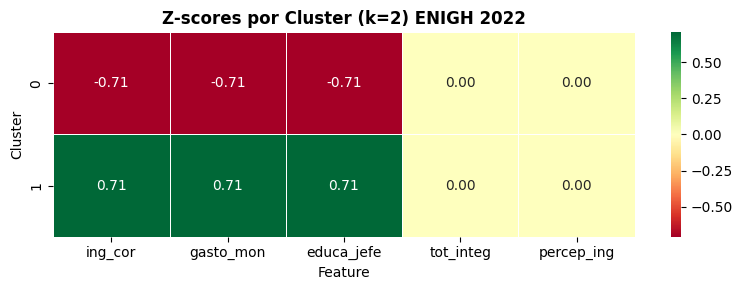

In [11]:
# Heatmap de z-scores por cluster
zscores = profile.apply(lambda col: (col - col.mean()) / (col.std() + 1e-9), axis=0)

fig, ax = plt.subplots(figsize=(max(8, len(feats_ok)), best_k+1))
sns.heatmap(zscores, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax)
ax.set_title(f'Z-scores por Cluster (k={best_k}) ENIGH 2022', fontweight='bold')
ax.set_xlabel('Feature'); ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('kmeans_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

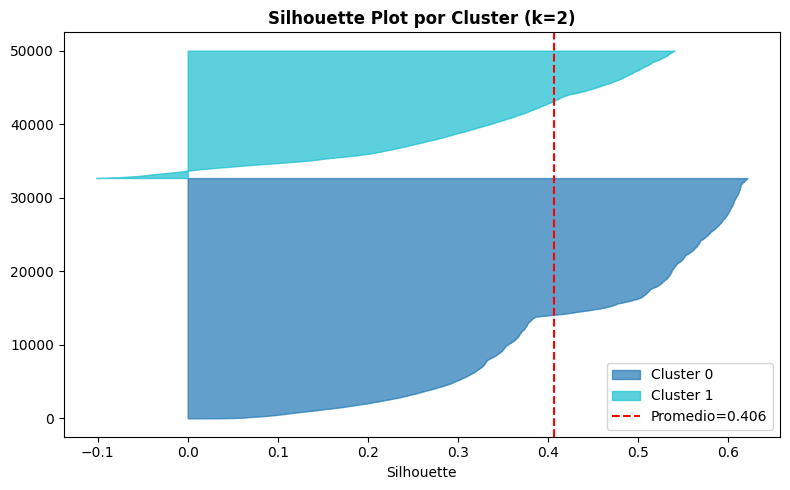

In [12]:
# Silhouette plot por cluster
X_best = best_km_info['_X']
sil_vals = silhouette_samples(X_best, best_labels)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, best_k))
for i in range(best_k):
    ith = np.sort(sil_vals[best_labels == i])
    size_i = ith.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                      alpha=0.7, color=colors[i], label=f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(np.mean(sil_vals), color='red', ls='--',
            label=f'Promedio={np.mean(sil_vals):.3f}')
ax.set_xlabel('Silhouette')
ax.set_title(f'Silhouette Plot por Cluster (k={best_k})', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Interpretación de los clusters

In [13]:
# Asignar nombres según perfil

ing_med = profile['ing_cor'] if 'ing_cor' in profile.columns else profile.iloc[:,0]
order   = ing_med.argsort().values  # índices ordenados por ingreso

nombres_base = [
    'Hogar vulnerable bajo ingreso, sin cobertura de salud',
    'Clase media-baja ingreso moderado, derechohabiencia IMSS/ISSSTE',
    'Clase media ingreso medio, gasto en salud moderado',
    'Clase media-alta ingreso alto, seguro social + privado',
    'Alto ingreso bienes de calidad, seguro privado predominante',
    'Cluster adicional 5',
    'Cluster adicional 6',
]

nombres = {order[i]: nombres_base[i] for i in range(best_k)}
print('Nombres actuariales de clusters ')
for c, nm in sorted(nombres.items()):
    print(f'Cluster {c}: {nm}')

df_p2['segmento'] = df_p2['cluster'].map(nombres)
print('\nDistribución por segmento:')
display(df_p2['segmento'].value_counts().to_frame())

Nombres actuariales de clusters 
Cluster 0: Hogar vulnerable bajo ingreso, sin cobertura de salud
Cluster 1: Clase media-baja ingreso moderado, derechohabiencia IMSS/ISSSTE

Distribución por segmento:


,count
segmento,
"Hogar vulnerable bajo ingreso, sin cobertura de salud",32682
"Clase media-baja ingreso moderado, derechohabiencia IMSS/ISSSTE",17318


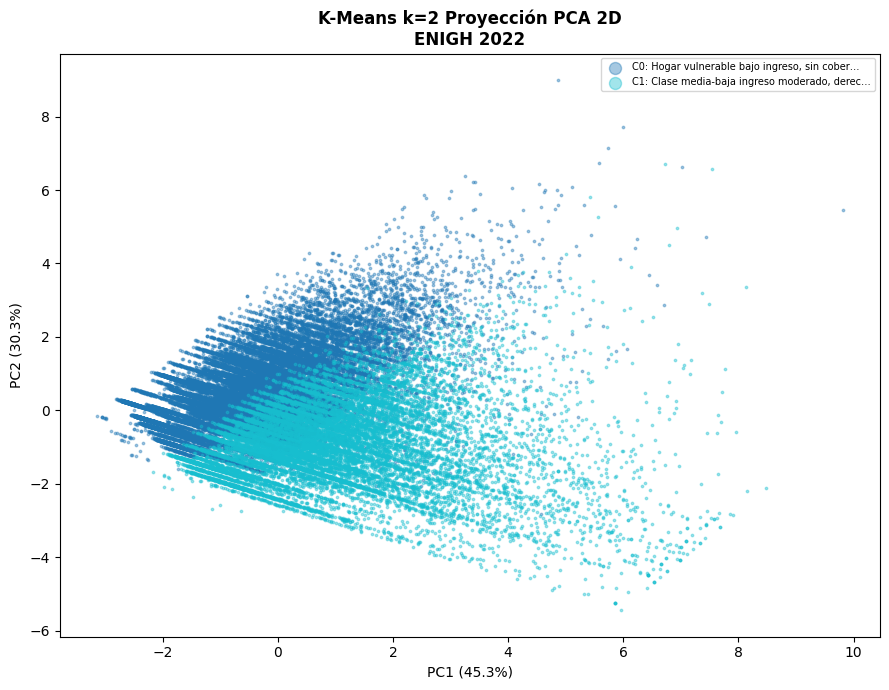

In [14]:
# Visualización 2D con PCA
pca_2d = PCA(n_components=2, random_state=SEED)
X_2d   = pca_2d.fit_transform(scaler_std.transform(X_p2))

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, best_k))
for c in range(best_k):
    mask = best_labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                s=3, alpha=0.4, color=colors[c],
                label=f'C{c}: {nombres.get(c,str(c))[:40]}…')

ax.set_title(f'K-Means k={best_k} Proyección PCA 2D\nENIGH 2022',
              fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=7, markerscale=5, loc='upper right')
plt.tight_layout()
plt.savefig('kmeans_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusiones

El análisis realizado permitió identificar grupos de hogares con características socioeconómicas similares mediante técnicas de aprendizaje no supervisado. La combinación de reducción de dimensionalidad mediante PCA y agrupamiento con K-Means facilitó la detección de patrones relevantes en un conjunto de datos de alta dimensionalidad.

Los resultados muestran que existen diferencias significativas entre los grupos identificados en variables relacionadas con ingresos, condiciones de vivienda, educación y acceso a bienes y servicios. Estas diferencias sugieren que la población no puede ser tratada como un conjunto homogéneo, sino como segmentos con necesidades y características particulares.

## Posibles aplicaciones

* Diseño de políticas públicas: Los segmentos identificados pueden utilizarse para dirigir apoyos sociales o programas gubernamentales a grupos específicos de la población.
* Focalización de recursos: Instituciones públicas y privadas podrían asignar recursos de manera más eficiente considerando las características predominantes de cada segmento.
* Estudios de mercado: Empresas pueden utilizar este tipo de segmentación para comprender mejor distintos perfiles de consumidores y adaptar productos o servicios a cada grupo.
* Planeación territorial: La identificación de patrones socioeconómicos permite detectar regiones o comunidades con necesidades específicas de infraestructura, educación o salud.

## Trabajo futuro

Como extensión de este proyecto, podrían explorarse otros algoritmos de agrupamiento como Clustering Jerárquico, DBSCAN para comparar la estabilidad de los segmentos encontrados. Asimismo, la incorporación de información geográfica permitiría analizar la distribución espacial de los grupos identificados y generar estrategias de intervención más precisas.

En conclusión, las técnicas de reducción de dimensionalidad y segmentación demostraron ser herramientas efectivas para transformar grandes volúmenes de datos socioeconómicos en información interpretable y útil para la toma de decisiones basada en evidencia.
